<a href="https://colab.research.google.com/github/sambhavgoel495/house-price-prediction-model/blob/main/housepriceprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

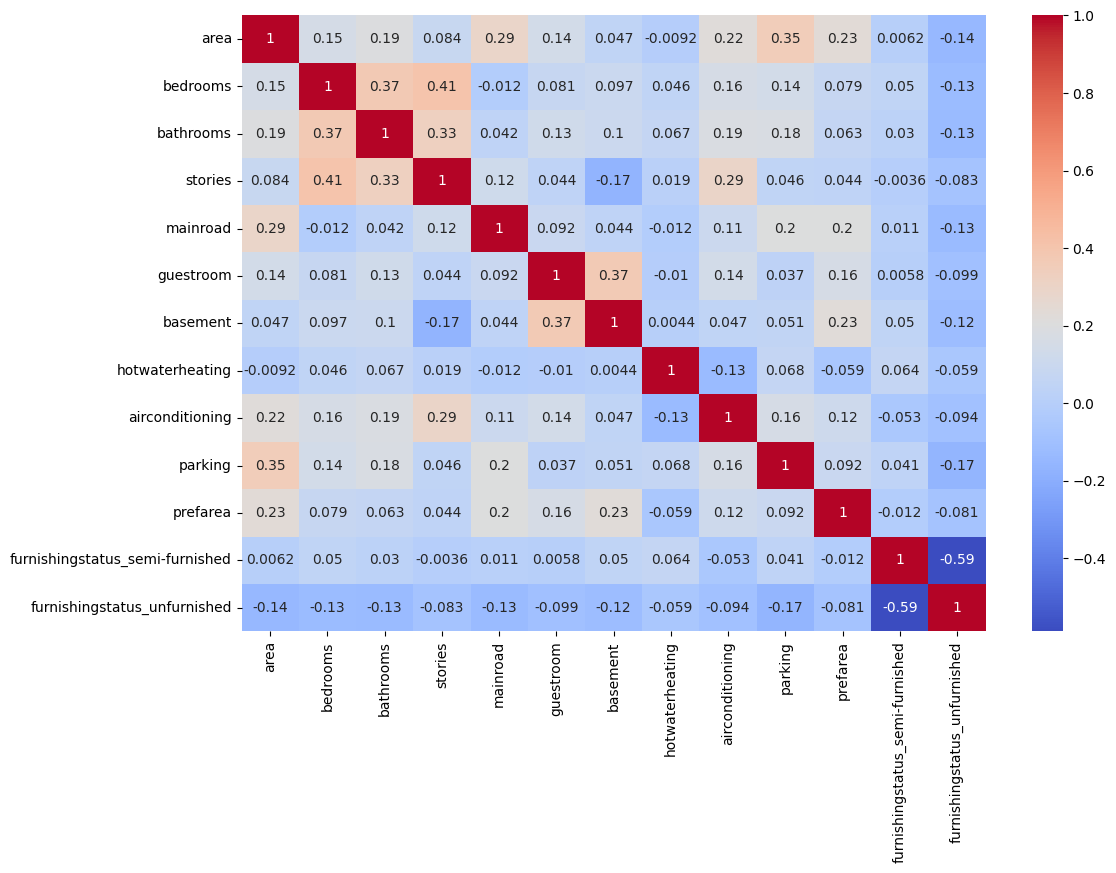

Mean Absolute Error (MAE): 970043.4039201637
Mean Squared Error (MSE): 1754318687330.6633
Root Mean Squared Error (RMSE): 1324506.9600914384
R² Score: 0.6529242642153185
0.6859438988560158
0.6529242642153185


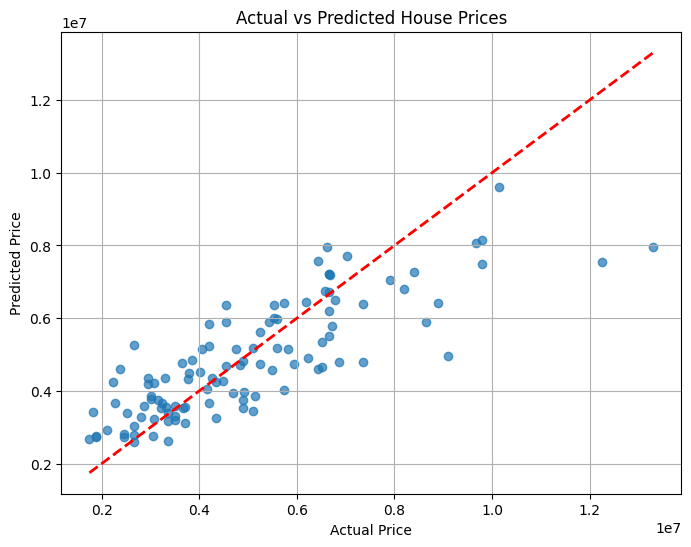

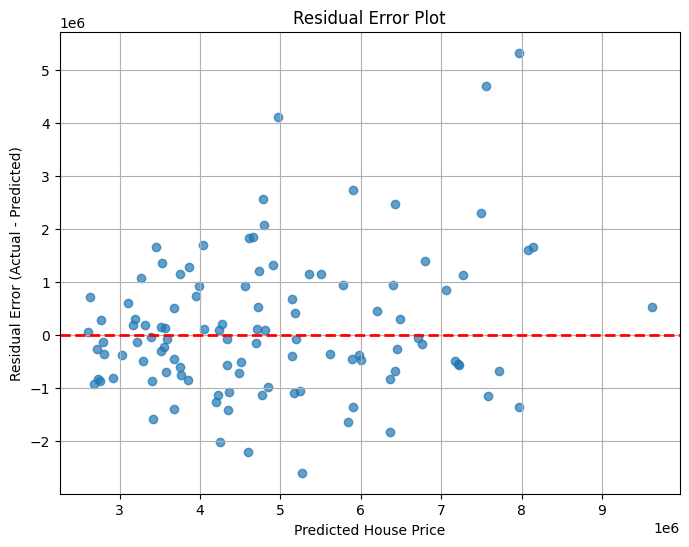

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt



# data loading
data=pd.read_csv("/content/house price prediction.zip");
x=data.drop('price',axis=1)
y=data['price']

# data preprocessing
x["mainroad"] = x["mainroad"].map({"yes": 1, "no": 0})
x["guestroom"] = x["guestroom"].map({"yes": 1, "no": 0})
x["basement"] = x["basement"].map({"yes": 1, "no": 0})
x["hotwaterheating"] = x["hotwaterheating"].map({"yes": 1, "no": 0})
x["airconditioning"] = x["airconditioning"].map({"yes": 1, "no": 0})
x["prefarea"] = x["prefarea"].map({"yes": 1, "no": 0})
x = pd.get_dummies(x, columns=["furnishingstatus"], drop_first=True)

# correlation metrics
plt.figure(figsize=(12,8))
sns.heatmap(x.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


# train-test split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

model1=LinearRegression()
model1.fit(x_train,y_train)
y_pred = model1.predict(x_test)


# evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


# training vs testing (to check for over and under fitting)
train_score = model1.score(x_train, y_train)
test_score = model1.score(x_test, y_test)
print(train_score)
print(test_score)



# actual vs predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)

plt.show()


# residual plot
residuals = y_test - y_pred


plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.7)


plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual Error (Actual - Predicted)")
plt.title("Residual Error Plot")
plt.grid(True)

plt.show()



